In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("food_wastage_data.csv")
df

,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Purchase History,Seasonality,Preparation Method,Geographical Location,Pricing,Wastage Food Amount
0,Meat,310,Corporate,450,Refrigerated,Regular,All Seasons,Buffet,Urban,Low,25
1,Meat,400,Birthday,500,Room Temperature,Regular,Winter,Buffet,Suburban,High,40
2,Vegetables,302,Birthday,371,Refrigerated,Regular,Summer,Buffet,Suburban,Low,27
3,Meat,491,Birthday,497,Refrigerated,Regular,All Seasons,Finger Food,Rural,High,32
4,Meat,300,Corporate,400,Refrigerated,Regular,Winter,Finger Food,Urban,Moderate,25
...,...,...,...,...,...,...,...,...,...,...,...
1777,Baked Goods,310,Corporate,350,Room Temperature,Regular,Summer,Finger Food,Urban,High,35
1778,Baked Goods,284,Social Gathering,443,Room Temperature,Regular,Winter,Buffet,Rural,Low,32
1779,Fruits,220,Wedding,300,Room Temperature,Regular,All Seasons,Finger Food,Urban,Moderate,15
1780,Fruits,250,Wedding,350,Room Temperature,Regular,All Seasons,Finger Food,Rural,Moderate,20


In [3]:
df.head()

,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Purchase History,Seasonality,Preparation Method,Geographical Location,Pricing,Wastage Food Amount
0,Meat,310,Corporate,450,Refrigerated,Regular,All Seasons,Buffet,Urban,Low,25
1,Meat,400,Birthday,500,Room Temperature,Regular,Winter,Buffet,Suburban,High,40
2,Vegetables,302,Birthday,371,Refrigerated,Regular,Summer,Buffet,Suburban,Low,27
3,Meat,491,Birthday,497,Refrigerated,Regular,All Seasons,Finger Food,Rural,High,32
4,Meat,300,Corporate,400,Refrigerated,Regular,Winter,Finger Food,Urban,Moderate,25


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1782 entries, 0 to 1781
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Type of Food           1782 non-null   object
 1   Number of Guests       1782 non-null   int64 
 2   Event Type             1782 non-null   object
 3   Quantity of Food       1782 non-null   int64 
 4   Storage Conditions     1782 non-null   object
 5   Purchase History       1782 non-null   object
 6   Seasonality            1782 non-null   object
 7   Preparation Method     1782 non-null   object
 8   Geographical Location  1782 non-null   object
 9   Pricing                1782 non-null   object
 10  Wastage Food Amount    1782 non-null   int64 
dtypes: int64(3), object(8)
memory usage: 153.3+ KB


In [5]:
df.describe()

,Number of Guests,Quantity of Food,Wastage Food Amount
count,1782.000000,1782.000000,1782.000000
mean,317.804714,411.125701,28.536476
std,67.829658,65.204674,10.461317
min,207.000000,280.000000,10.000000
25%,267.000000,350.000000,20.000000
50%,302.000000,400.000000,26.500000
75%,350.000000,480.000000,35.000000
max,491.000000,500.000000,63.000000


In [6]:
df.isnull().sum()

Type of Food             0
Number of Guests         0
Event Type               0
Quantity of Food         0
Storage Conditions       0
Purchase History         0
Seasonality              0
Preparation Method       0
Geographical Location    0
Pricing                  0
Wastage Food Amount      0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(164)

In [8]:
# Categorical columns ki unique values
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Type of Food ---
Type of Food
Meat              437
Baked Goods       419
Dairy Products    387
Fruits            328
Vegetables        211
Name: count, dtype: int64

--- Event Type ---
Event Type
Corporate           515
Social Gathering    461
Wedding             438
Birthday            368
Name: count, dtype: int64

--- Storage Conditions ---
Storage Conditions
Room Temperature    1157
Refrigerated         625
Name: count, dtype: int64

--- Purchase History ---
Purchase History
Regular       1576
Occasional     206
Name: count, dtype: int64

--- Seasonality ---
Seasonality
Winter         632
All Seasons    623
Summer         527
Name: count, dtype: int64

--- Preparation Method ---
Preparation Method
Sit-down Dinner    781
Finger Food        702
Buffet             299
Name: count, dtype: int64

--- Geographical Location ---
Geographical Location
Suburban    821
Urban       564
Rural       397
Name: count, dtype: int64

--- Pricing ---
Pricing
High        674
Moderate    673
Low 

In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 164


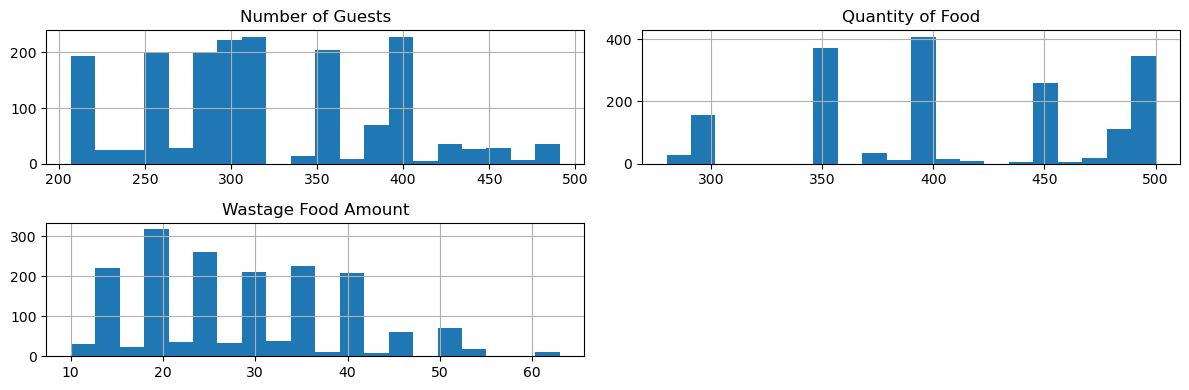

In [10]:
df[['Number of Guests', 'Quantity of Food', 'Wastage Food Amount']].hist(
    figsize=(12, 4),
    bins=20
)

plt.tight_layout()
plt.show()

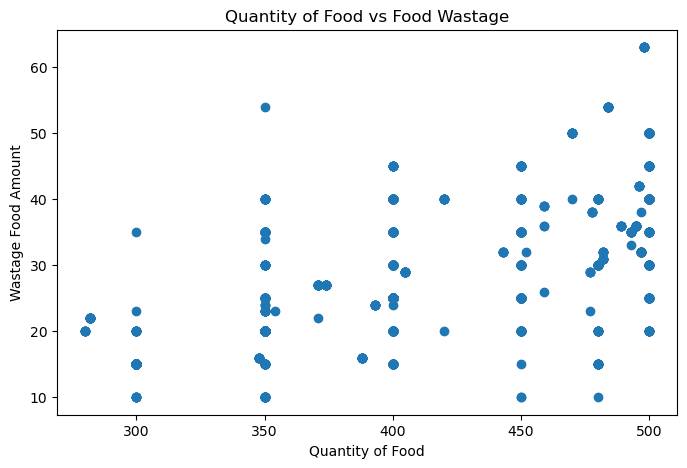

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Quantity of Food'],
    df['Wastage Food Amount'],
    
)

plt.xlabel('Quantity of Food')
plt.ylabel('Wastage Food Amount')
plt.title('Quantity of Food vs Food Wastage')

plt.show()

In [12]:
food_waste = df.groupby('Type of Food')['Wastage Food Amount'].mean().sort_values(ascending=False)

print(food_waste)

Type of Food
Fruits            29.472561
Baked Goods       28.811456
Meat              28.695652
Dairy Products    27.852713
Vegetables        27.459716
Name: Wastage Food Amount, dtype: float64


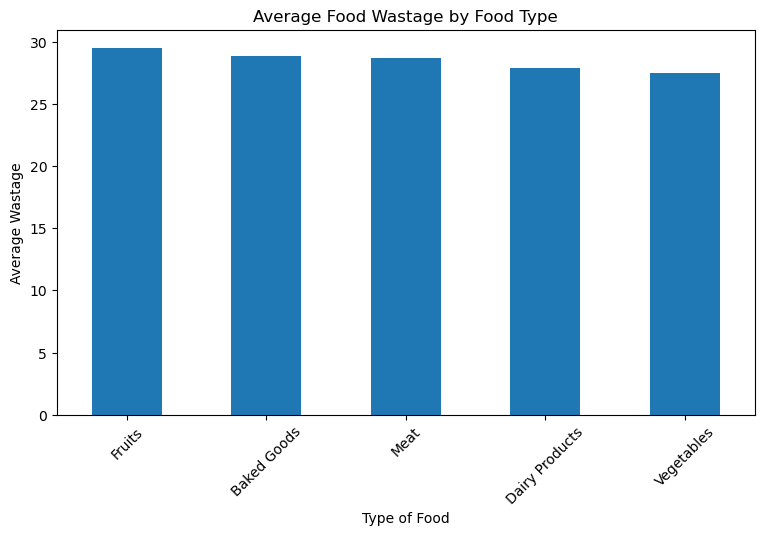

In [13]:
plt.figure(figsize=(9, 5))

food_waste.plot(kind='bar')

plt.xlabel('Type of Food')
plt.ylabel('Average Wastage')
plt.title('Average Food Wastage by Food Type')
plt.xticks(rotation=45)

plt.show()

In [14]:
event_waste = df.groupby('Event Type')['Wastage Food Amount'].mean().sort_values(ascending=False)

print(event_waste)

Event Type
Wedding             29.200913
Corporate           28.467961
Social Gathering    28.286334
Birthday            28.154891
Name: Wastage Food Amount, dtype: float64


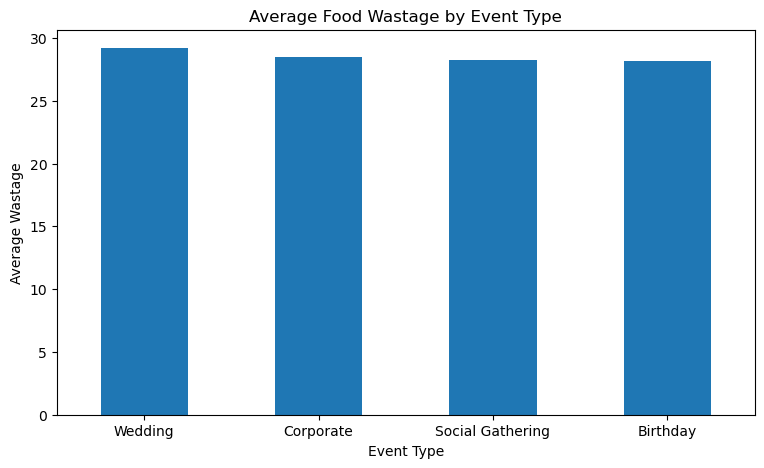

In [15]:
plt.figure(figsize=(9, 5))

event_waste.plot(kind='bar')

plt.xlabel('Event Type')
plt.ylabel('Average Wastage')
plt.title('Average Food Wastage by Event Type')
plt.xticks(rotation=0)

plt.show()



In [16]:
storage_waste = df.groupby('Storage Conditions')['Wastage Food Amount'].mean()

print(storage_waste)

Storage Conditions
Refrigerated        28.961600
Room Temperature    28.306828
Name: Wastage Food Amount, dtype: float64


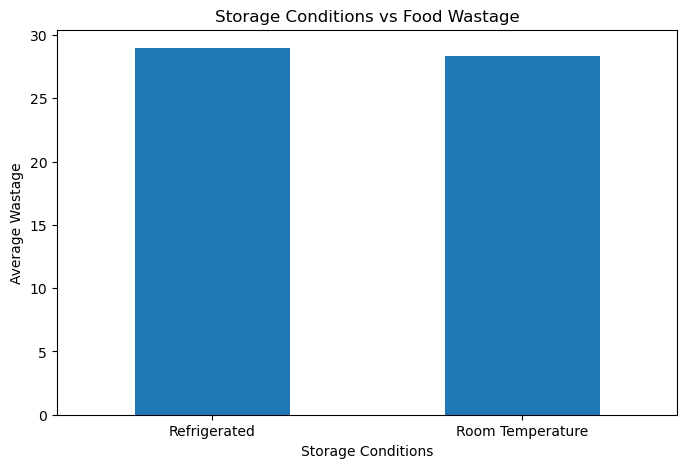

In [17]:
plt.figure(figsize=(8, 5))

storage_waste.plot(kind='bar')

plt.xlabel('Storage Conditions')
plt.ylabel('Average Wastage')
plt.title('Storage Conditions vs Food Wastage')
plt.xticks(rotation=0)

plt.show()

In [18]:
prep_waste = df.groupby('Preparation Method')['Wastage Food Amount'].mean().sort_values(ascending=False)

print(prep_waste)

Preparation Method
Sit-down Dinner    33.033291
Buffet             29.474916
Finger Food        23.133903
Name: Wastage Food Amount, dtype: float64


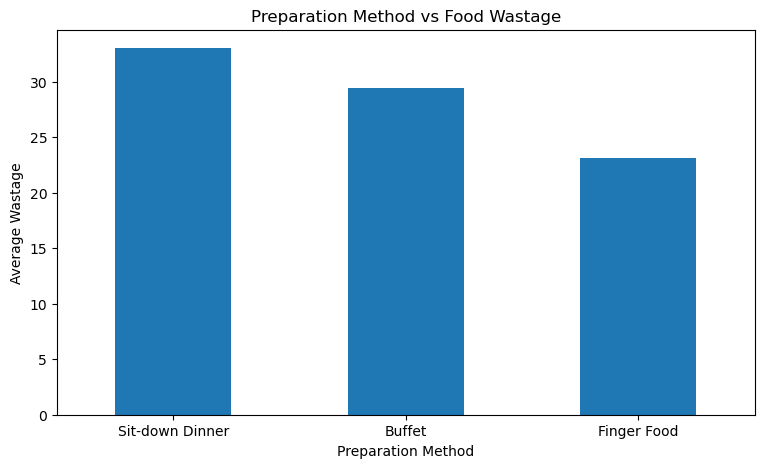

In [19]:
plt.figure(figsize=(9, 5))

prep_waste.plot(kind='bar')

plt.xlabel('Preparation Method')
plt.ylabel('Average Wastage')
plt.title('Preparation Method vs Food Wastage')
plt.xticks(rotation=0)

plt.show()

In [20]:
df['Wastage Rate'] = (
    df['Wastage Food Amount'] / df['Quantity of Food']
) * 100

df[['Quantity of Food', 'Wastage Food Amount', 'Wastage Rate']].head()

,Quantity of Food,Wastage Food Amount,Wastage Rate
0,450,25,5.555556
1,500,40,8.000000
2,371,27,7.277628
3,497,32,6.438632
4,400,25,6.250000


In [21]:
df['Wastage Rate'].describe()

count    1782.000000
mean        6.852748
std         1.998889
min         2.083333
25%         5.555556
50%         6.438632
75%         8.000000
max        15.428571
Name: Wastage Rate, dtype: float64

In [22]:
df.sort_values('Wastage Rate', ascending=False)[
    ['Type of Food',
     'Number of Guests',
     'Event Type',
     'Quantity of Food',
     'Wastage Food Amount',
     'Wastage Rate']
].head(10)

,Type of Food,Number of Guests,Event Type,Quantity of Food,Wastage Food Amount,Wastage Rate
1653,Fruits,350,Corporate,350,54,15.428571
1269,Fruits,488,Corporate,498,63,12.650602
334,Baked Goods,488,Corporate,498,63,12.650602
211,Dairy Products,488,Corporate,498,63,12.650602
928,Meat,488,Wedding,498,63,12.650602
1007,Baked Goods,488,Wedding,498,63,12.650602
1327,Dairy Products,488,Corporate,498,63,12.650602
263,Fruits,488,Corporate,498,63,12.650602
1741,Baked Goods,488,Corporate,498,63,12.650602
1298,Fruits,488,Social Gathering,498,63,12.650602


In [23]:
# Correlation matrix
corr = df[
    ['Number of Guests', 'Quantity of Food', 'Wastage Food Amount', 'Wastage Rate']
].corr()

corr

,Number of Guests,Quantity of Food,Wastage Food Amount,Wastage Rate
Number of Guests,1.000000,0.794401,0.650421,0.391904
Quantity of Food,0.794401,1.000000,0.638648,0.278716
Wastage Food Amount,0.650421,0.638648,1.000000,0.908208
Wastage Rate,0.391904,0.278716,0.908208,1.000000


In [24]:
import seaborn as sns

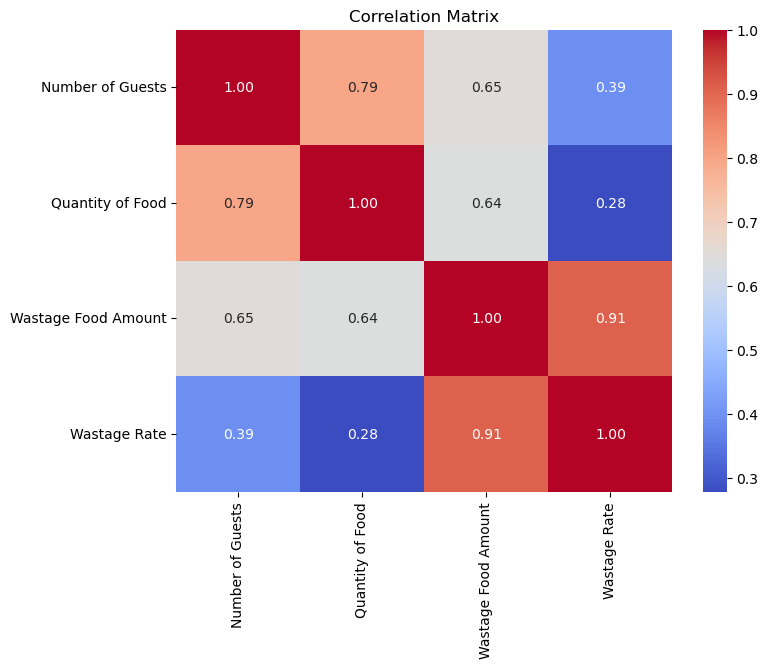

In [25]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

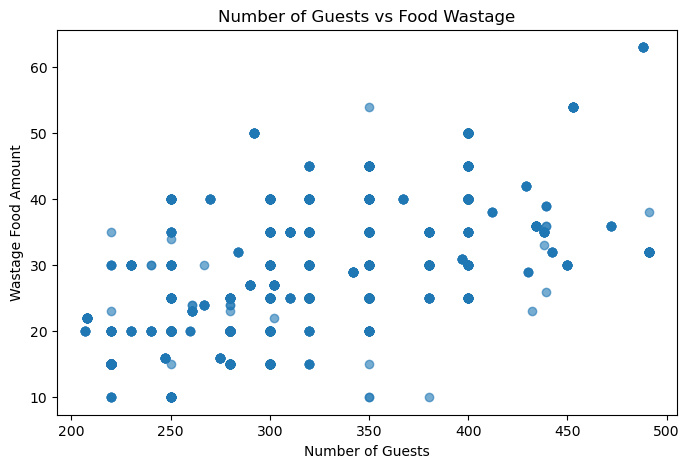

In [26]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Number of Guests'],
    df['Wastage Food Amount'],
    alpha=0.6
)

plt.xlabel('Number of Guests')
plt.ylabel('Wastage Food Amount')
plt.title('Number of Guests vs Food Wastage')

plt.show()

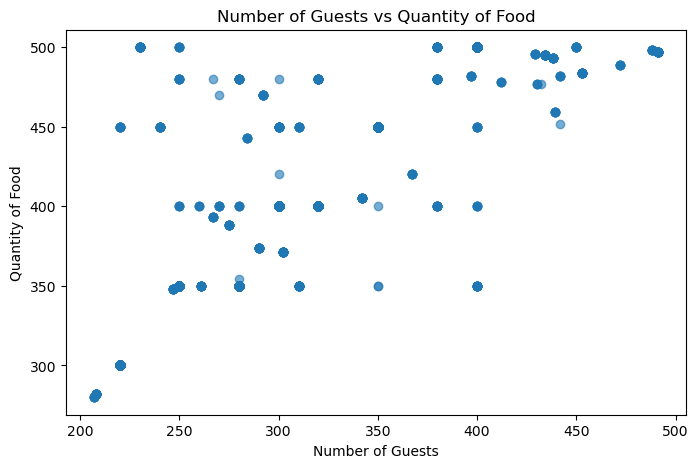

In [27]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Number of Guests'],
    df['Quantity of Food'],
    alpha=0.6
)

plt.xlabel('Number of Guests')
plt.ylabel('Quantity of Food')
plt.title('Number of Guests vs Quantity of Food')

plt.show()

In [28]:
df['Food per Guest'] = (
    df['Quantity of Food'] / df['Number of Guests']
)

df['Waste per Guest'] = (
    df['Wastage Food Amount'] / df['Number of Guests']
)

df[['Food per Guest', 'Waste per Guest']].head()

,Food per Guest,Waste per Guest
0,1.451613,0.080645
1,1.250000,0.100000
2,1.228477,0.089404
3,1.012220,0.065173
4,1.333333,0.083333


In [29]:
df.describe()

,Number of Guests,Quantity of Food,Wastage Food Amount,Wastage Rate,Food per Guest,Waste per Guest
count,1782.000000,1782.000000,1782.000000,1782.000000,1782.000000,1782.000000
mean,317.804714,411.125701,28.536476,6.852748,1.316903,0.089212
std,67.829658,65.204674,10.461317,1.998889,0.182303,0.025564
min,207.000000,280.000000,10.000000,2.083333,0.875000,0.026316
25%,267.000000,350.000000,20.000000,5.555556,1.250000,0.071429
50%,302.000000,400.000000,26.500000,6.438632,1.285714,0.083333
75%,350.000000,480.000000,35.000000,8.000000,1.363636,0.105769
max,491.000000,500.000000,63.000000,15.428571,2.173913,0.171233


In [30]:
# Remove duplicate rows
print("Before removing duplicates:", df.shape)

df = df.drop_duplicates().reset_index(drop=True)

print("After removing duplicates:", df.shape)

Before removing duplicates: (1782, 14)
After removing duplicates: (1618, 14)


In [31]:
df['Food per Guest'] = (
    df['Quantity of Food'] / df['Number of Guests']
)

In [32]:
df['Waste per Guest'] = (
    df['Wastage Food Amount'] / df['Number of Guests']
)

In [33]:
df[
    ['Number of Guests',
     'Quantity of Food',
     'Wastage Food Amount',
     'Food per Guest',
     'Waste per Guest']
].head()

,Number of Guests,Quantity of Food,Wastage Food Amount,Food per Guest,Waste per Guest
0,310,450,25,1.451613,0.080645
1,400,500,40,1.250000,0.100000
2,302,371,27,1.228477,0.089404
3,491,497,32,1.012220,0.065173
4,300,400,25,1.333333,0.083333


In [34]:
df[['Food per Guest', 'Waste per Guest']].describe()

,Food per Guest,Waste per Guest
count,1618.000000,1618.000000
mean,1.319124,0.089498
std,0.189375,0.025850
min,0.875000,0.026316
25%,1.250000,0.071429
50%,1.285714,0.083333
75%,1.363636,0.105769
max,2.173913,0.171233


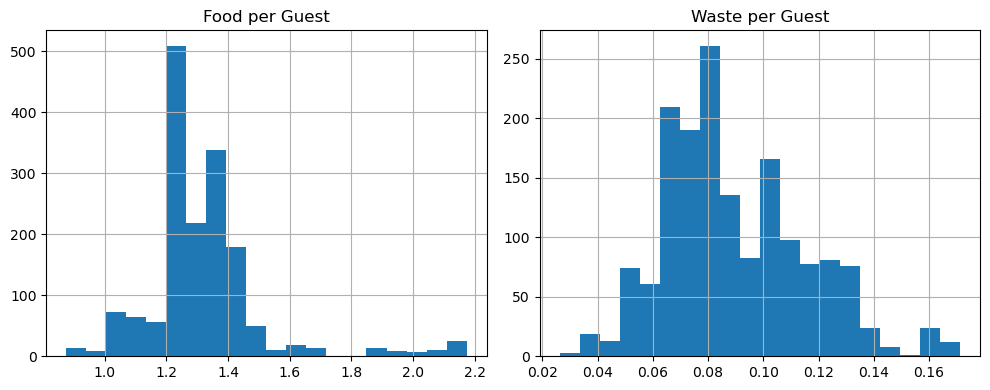

In [35]:
df[['Food per Guest', 'Waste per Guest']].hist(
    figsize=(10, 4),
    bins=20
)

plt.tight_layout()
plt.show()

In [36]:
# Features
X = df[
    [
        'Type of Food',
        'Number of Guests',
        'Event Type',
        'Quantity of Food',
        'Storage Conditions',
        'Purchase History',
        'Seasonality',
        'Preparation Method',
        'Geographical Location',
        'Pricing',
        'Food per Guest'
    ]
]

# Target
y = df['Wastage Food Amount']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1618, 11)
Target shape: (1618,)


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1294, 11)
Testing data: (324, 11)


In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    'Type of Food',
    'Event Type',
    'Storage Conditions',
    'Purchase History',
    'Seasonality',
    'Preparation Method',
    'Geographical Location',
    'Pricing'
]

numerical_features = [
    'Number of Guests',
    'Quantity of Food',
    'Food per Guest'
]

In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    'Type of Food',
    'Event Type',
    'Storage Conditions',
    'Purchase History',
    'Seasonality',
    'Preparation Method',
    'Geographical Location',
    'Pricing'
]

numerical_features = [
    'Number of Guests',
    'Quantity of Food',
    'Food per Guest'
]

In [40]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        ),
        (
            'num',
            'passthrough',
            numerical_features
        )
    ]
)

In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'regressor',
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                max_depth=None,
                min_samples_split=2
            )
        )
    ]
)

In [42]:
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [43]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[17.19555556 34.99666667 30.96666667 20.06666667 19.93333333 19.98666667
 36.15333333 58.83       34.32333333 19.7       ]


In [44]:
comparison = pd.DataFrame({
    'Actual Wastage': y_test.values,
    'Predicted Wastage': y_pred
})

comparison.head(10)

,Actual Wastage,Predicted Wastage
0,15,17.195556
1,35,34.996667
2,32,30.966667
3,20,20.066667
4,20,19.933333
5,20,19.986667
6,36,36.153333
7,63,58.830000
8,32,34.323333
9,20,19.700000


In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 2))

MAE : 1.84
RMSE: 3.0
R²  : 0.92


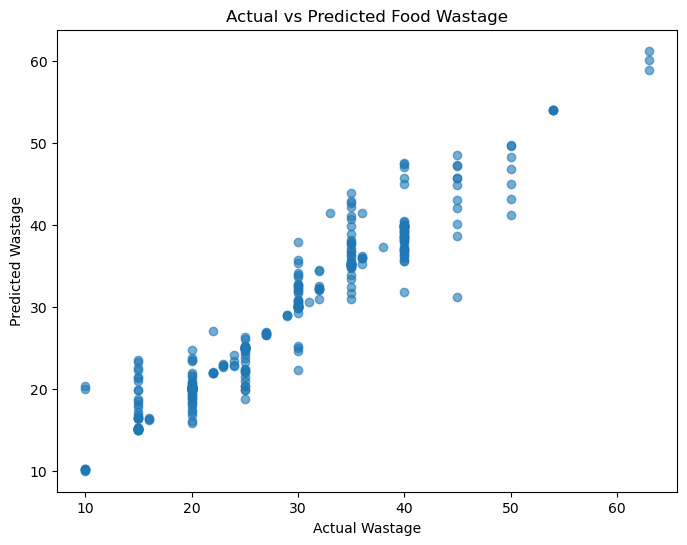

In [46]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel('Actual Wastage')
plt.ylabel('Predicted Wastage')
plt.title('Actual vs Predicted Food Wastage')

plt.show()

In [47]:
# Get trained Random Forest
rf_model = model.named_steps['regressor']

# Get feature names after One-Hot Encoding
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

# Feature importance
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values('Importance', ascending=False)

feature_importance.head(15)

,Feature,Importance
22,cat__Pricing_High,0.587548
25,num__Number of Guests,0.131601
26,num__Quantity of Food,0.082949
27,num__Food per Guest,0.078597
18,cat__Preparation Method_Sit-down Dinner,0.029237
16,cat__Preparation Method_Buffet,0.010760
23,cat__Pricing_Low,0.006991
17,cat__Preparation Method_Finger Food,0.006928
24,cat__Pricing_Moderate,0.006525
21,cat__Geographical Location_Urban,0.005247


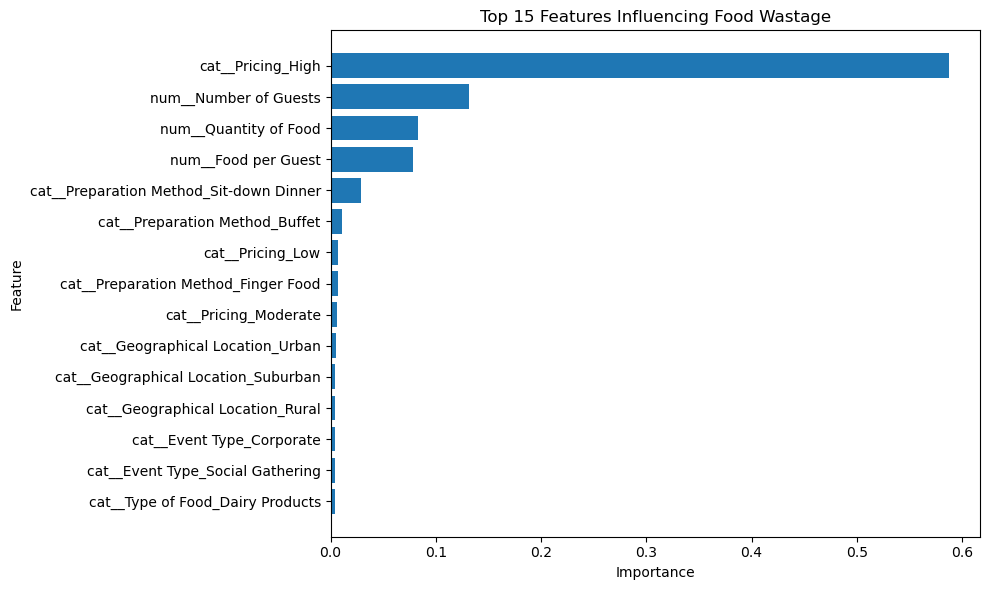

In [48]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(15).sort_values('Importance')

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 15 Features Influencing Food Wastage')

plt.tight_layout()
plt.show()

In [49]:
import sys
!{sys.executable} -m pip install shap

Defaulting to user installation because normal site-packages is not writeable


In [50]:
import sys

print(sys.executable)


C:\ProgramData\anaconda3\python.exe


In [51]:
!{sys.executable} -m pip show shap

Name: shap
Version: 0.52.0
Summary: A unified approach to explain the output of any machine learning model.
Home-page: 
Author: 
Author-email: Scott Lundberg <slund1@cs.washington.edu>
License: MIT License
Location: C:\Users\HP\AppData\Roaming\Python\Python313\site-packages
Requires: cloudpickle, llvmlite, numba, numpy, packaging, pandas, scikit-learn, scipy, slicer, tqdm
Required-by: 


In [52]:
import shap

print("SHAP imported successfully!")
print(shap.__version__)

SHAP imported successfully!
0.52.0


In [53]:
X_train_transformed = model.named_steps['preprocessor'].transform(X_train)
X_test_transformed = model.named_steps['preprocessor'].transform(X_test)

feature_names = model.named_steps[
    'preprocessor'
].get_feature_names_out()

In [54]:
explainer = shap.TreeExplainer(
    model.named_steps['regressor']
)

shap_values = explainer.shap_values(
    X_test_transformed
)

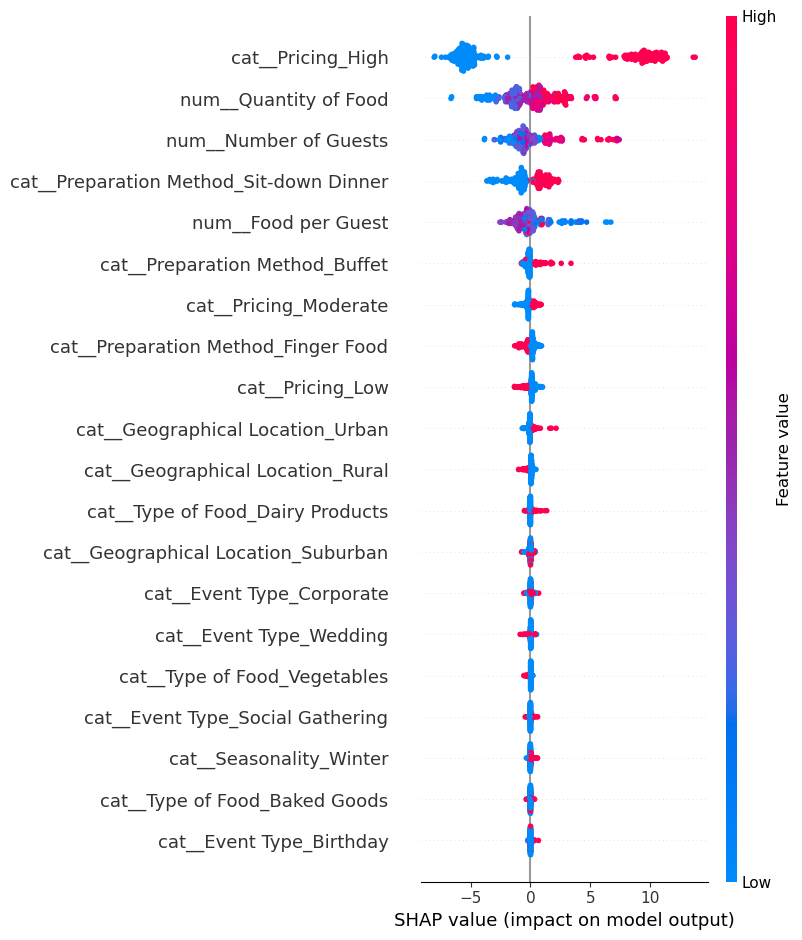

In [55]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

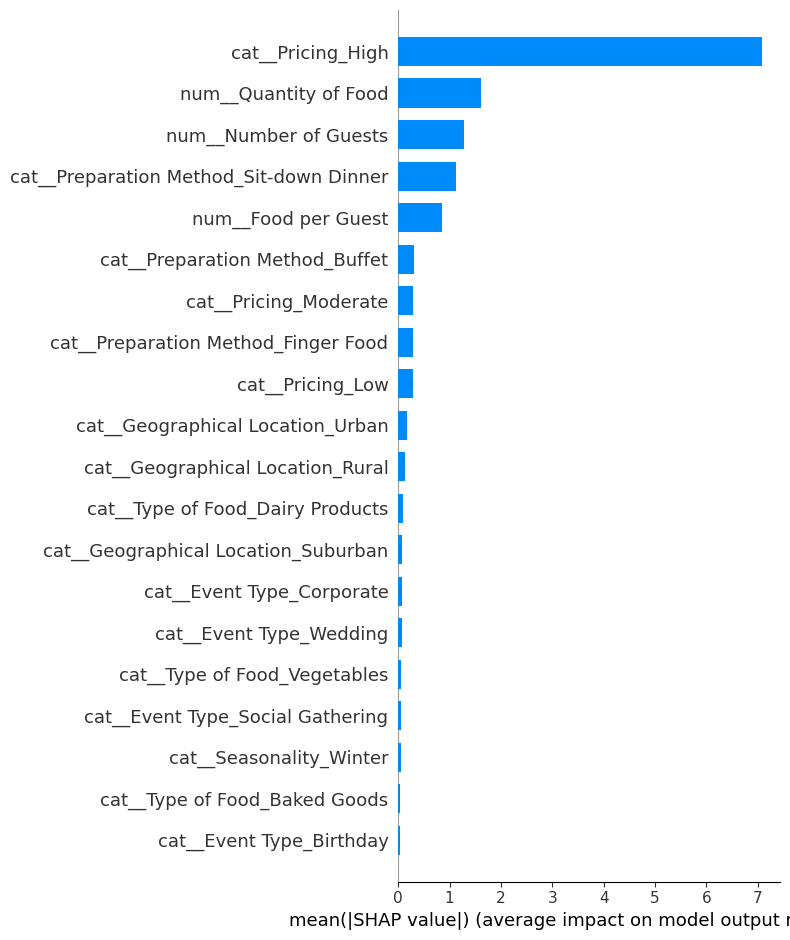

In [56]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type='bar'
)

In [57]:
def predict_food_waste(input_data):
    
    input_df = pd.DataFrame([input_data])
    
    # Food per Guest calculate
    input_df['Food per Guest'] = (
        input_df['Quantity of Food'] /
        input_df['Number of Guests']
    )
    
    predicted_waste = model.predict(input_df)[0]
    
    return predicted_waste

In [58]:
def food_recommendation(input_data):
    
    # Current quantity
    current_quantity = input_data['Quantity of Food']
    
    # Predict waste
    predicted_waste = predict_food_waste(input_data)
    
    # Waste rate
    waste_rate = (predicted_waste / current_quantity) * 100
    
    # Reduce only 50% of predicted waste
    # This provides a conservative recommendation
    reduction_factor = 0.50
    
    recommended_quantity = (
        current_quantity -
        (predicted_waste * reduction_factor)
    )
    
    # Expected waste after recommendation
    estimated_waste_reduction = (
        current_quantity - recommended_quantity
    )
    
    # Risk level
    if waste_rate < 10:
        risk = "Low"
    elif waste_rate < 20:
        risk = "Medium"
    else:
        risk = "High"
    
    return {
        "Predicted Waste": predicted_waste,
        "Waste Rate": waste_rate,
        "Risk Level": risk,
        "Recommended Quantity": recommended_quantity,
        "Potential Quantity Reduction": estimated_waste_reduction
    }

In [59]:
sample_input = {
    'Type of Food': 'Meat',
    'Number of Guests': 200,
    'Event Type': 'Wedding',
    'Quantity of Food': 300,
    'Storage Conditions': 'Refrigerated',
    'Purchase History': 'Regular',
    'Seasonality': 'Summer',
    'Preparation Method': 'Buffet',
    'Geographical Location': 'Urban',
    'Pricing': 'High'
}

result = food_recommendation(sample_input)

result

{'Predicted Waste': np.float64(29.216666666666665),
 'Waste Rate': np.float64(9.738888888888889),
 'Risk Level': 'Low',
 'Recommended Quantity': np.float64(285.39166666666665),
 'Potential Quantity Reduction': np.float64(14.608333333333348)}

In [60]:
print("🍽️ SMART FOOD WASTE RECOMMENDATION")
print("-----------------------------------")

print(f"Predicted Food Waste   : {result['Predicted Waste']:.2f} units")
print(f"Predicted Waste Rate   : {result['Waste Rate']:.2f}%")
print(f"Waste Risk Level       : {result['Risk Level']}")
print(f"Current Food Quantity  : {sample_input['Quantity of Food']:.2f} units")
print(f"Recommended Quantity   : {result['Recommended Quantity']:.2f} units")
print(f"Potential Reduction    : {result['Potential Quantity Reduction']:.2f} units")

🍽️ SMART FOOD WASTE RECOMMENDATION
-----------------------------------
Predicted Food Waste   : 29.22 units
Predicted Waste Rate   : 9.74%
Waste Risk Level       : Low
Current Food Quantity  : 300.00 units
Recommended Quantity   : 285.39 units
Potential Reduction    : 14.61 units


In [61]:
def optimize_food_quantity(input_data, min_percentage=0.85, step=5):
    
    current_quantity = input_data['Quantity of Food']
    
    # Minimum quantity to test
    min_quantity = current_quantity * min_percentage
    
    # Candidate quantities
    candidate_quantities = np.arange(
        min_quantity,
        current_quantity + 1,
        step
    )
    
    results = []
    
    for quantity in candidate_quantities:
        
        # Create a copy of input
        test_input = input_data.copy()
        
        # Change quantity
        test_input['Quantity of Food'] = quantity
        
        # Predict waste
        predicted_waste = predict_food_waste(test_input)
        
        # Calculate predicted waste rate
        predicted_waste_rate = (
            predicted_waste / quantity
        ) * 100
        
        results.append({
            'Quantity': quantity,
            'Predicted Waste': predicted_waste,
            'Predicted Waste Rate': predicted_waste_rate
        })
    
    results_df = pd.DataFrame(results)
    
    # Find quantity with minimum predicted waste
    best_option = results_df.loc[
        results_df['Predicted Waste'].idxmin()
    ]
    
    return results_df, best_option

In [62]:
optimization_results, best_option = optimize_food_quantity(
    sample_input
)

optimization_results

,Quantity,Predicted Waste,Predicted Waste Rate
0,255.0,25.216667,9.888889
1,260.0,25.200000,9.692308
2,265.0,25.150000,9.490566
3,270.0,25.150000,9.314815
4,275.0,25.150000,9.145455
5,280.0,25.150000,8.982143
6,285.0,25.150000,8.824561
7,290.0,25.283333,8.718391
8,295.0,29.216667,9.903955
9,300.0,29.216667,9.738889


In [63]:
print("🍽️ FOOD QUANTITY OPTIMIZATION")
print("--------------------------------")

print(f"Current Quantity: {sample_input['Quantity of Food']:.2f} units")
print(f"Recommended Quantity: {best_option['Quantity']:.2f} units")
print(f"Expected Waste: {best_option['Predicted Waste']:.2f} units")
print(f"Expected Waste Rate: {best_option['Predicted Waste Rate']:.2f}%")

🍽️ FOOD QUANTITY OPTIMIZATION
--------------------------------
Current Quantity: 300.00 units
Recommended Quantity: 265.00 units
Expected Waste: 25.15 units
Expected Waste Rate: 9.49%


In [66]:
current_predicted_waste = predict_food_waste(sample_input)

recommended_quantity = best_option['Quantity']
recommended_predicted_waste = best_option['Predicted Waste']

potential_waste_reduction = (
    current_predicted_waste -
    recommended_predicted_waste
)

quantity_reduction = (
    sample_input['Quantity of Food'] -
    recommended_quantity
)

print("📊 COMPARISON")
print("--------------------------------")
print(f"Current Quantity            : {sample_input['Quantity of Food']:.2f}")
print(f"Recommended Quantity        : {recommended_quantity:.2f}")
print(f"Quantity Reduction          : {quantity_reduction:.2f}")
print(f"Current Predicted Waste     : {current_predicted_waste:.2f}")
print(f"Recommended Predicted Waste : {recommended_predicted_waste:.2f}")
print(f"Potential Waste Reduction   : {potential_waste_reduction:.2f}")

📊 COMPARISON
--------------------------------
Current Quantity            : 300.00
Recommended Quantity        : 265.00
Quantity Reduction          : 35.00
Current Predicted Waste     : 29.22
Recommended Predicted Waste : 25.15
Potential Waste Reduction   : 4.07


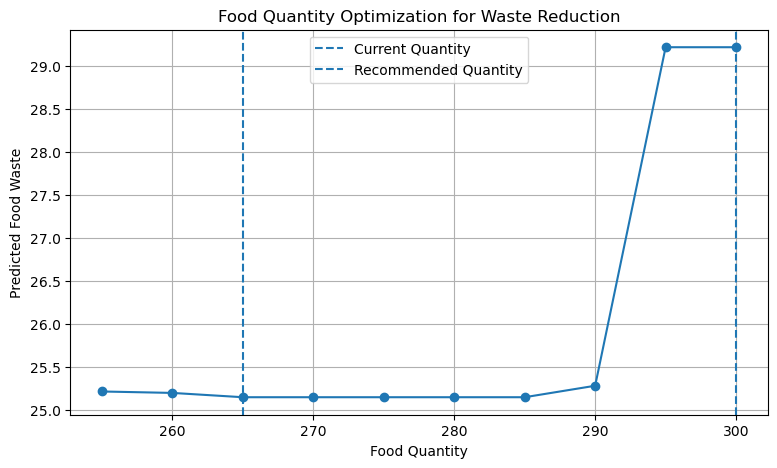

In [68]:
plt.figure(figsize=(9, 5))

plt.plot(
    optimization_results['Quantity'],
    optimization_results['Predicted Waste'],
    marker='o'
)

plt.axvline(
    sample_input['Quantity of Food'],
    linestyle='--',
    label='Current Quantity'
)

plt.axvline(
    recommended_quantity,
    linestyle='--',
    label='Recommended Quantity'
)

plt.xlabel('Food Quantity')
plt.ylabel('Predicted Food Waste')
plt.title('Food Quantity Optimization for Waste Reduction')

plt.legend()
plt.grid(True)

plt.show()

In [69]:
def smart_food_recommendation(input_data):
    
    # Current quantity
    current_quantity = input_data['Quantity of Food']
    
    # Current predicted waste
    current_waste = predict_food_waste(input_data)
    
    # Optimization
    optimization_results, best_option = optimize_food_quantity(
        input_data
    )
    
    # Recommended values
    recommended_quantity = best_option['Quantity']
    recommended_waste = best_option['Predicted Waste']
    
    # Calculations
    quantity_reduction = (
        current_quantity - recommended_quantity
    )
    
    waste_reduction = (
        current_waste - recommended_waste
    )
    
    current_waste_rate = (
        current_waste / current_quantity
    ) * 100
    
    recommended_waste_rate = (
        recommended_waste / recommended_quantity
    ) * 100
    
    # Risk level
    if current_waste_rate < 10:
        risk = "Low"
    elif current_waste_rate < 20:
        risk = "Medium"
    else:
        risk = "High"
    
    return {
        'Current Quantity': current_quantity,
        'Recommended Quantity': recommended_quantity,
        'Quantity Reduction': quantity_reduction,
        'Current Predicted Waste': current_waste,
        'Recommended Predicted Waste': recommended_waste,
        'Potential Waste Reduction': waste_reduction,
        'Current Waste Rate': current_waste_rate,
        'Recommended Waste Rate': recommended_waste_rate,
        'Risk Level': risk
    }

In [70]:
final_recommendation = smart_food_recommendation(sample_input)

final_recommendation

{'Current Quantity': 300,
 'Recommended Quantity': np.float64(265.0),
 'Quantity Reduction': np.float64(35.0),
 'Current Predicted Waste': np.float64(29.216666666666665),
 'Recommended Predicted Waste': np.float64(25.15),
 'Potential Waste Reduction': np.float64(4.066666666666666),
 'Current Waste Rate': np.float64(9.738888888888889),
 'Recommended Waste Rate': np.float64(9.490566037735848),
 'Risk Level': 'Low'}

In [71]:
print("🍽️ SMART FOOD WASTE INTELLIGENCE")
print("=" * 45)

print(f"Current Quantity       : {final_recommendation['Current Quantity']:.2f}")
print(f"Recommended Quantity   : {final_recommendation['Recommended Quantity']:.2f}")
print(f"Quantity Reduction     : {final_recommendation['Quantity Reduction']:.2f}")

print("-" * 45)

print(f"Current Predicted Waste      : {final_recommendation['Current Predicted Waste']:.2f}")
print(f"Recommended Predicted Waste  : {final_recommendation['Recommended Predicted Waste']:.2f}")
print(f"Potential Waste Reduction    : {final_recommendation['Potential Waste Reduction']:.2f}")

print("-" * 45)

print(f"Current Waste Rate       : {final_recommendation['Current Waste Rate']:.2f}%")
print(f"Recommended Waste Rate   : {final_recommendation['Recommended Waste Rate']:.2f}%")
print(f"Waste Risk Level         : {final_recommendation['Risk Level']}")

🍽️ SMART FOOD WASTE INTELLIGENCE
Current Quantity       : 300.00
Recommended Quantity   : 265.00
Quantity Reduction     : 35.00
---------------------------------------------
Current Predicted Waste      : 29.22
Recommended Predicted Waste  : 25.15
Potential Waste Reduction    : 4.07
---------------------------------------------
Current Waste Rate       : 9.74%
Recommended Waste Rate   : 9.49%
Waste Risk Level         : Low


In [72]:
import joblib

joblib.dump(model, "food_waste_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [73]:
import os

print(os.path.getsize("food_waste_model.pkl"), "bytes")

12083850 bytes


In [74]:
import streamlit

print("Streamlit version:", streamlit.__version__)

Streamlit version: 1.45.1
